# Sesión 9: EP Loss + Multi-Task Peak Head

## Objetivo
Mejorar la predicción de peaks y valleys del mejor modelo de Sesión 8 (LSTM+TDA v2, MAE=27.92) mediante:
1. **Enhanced Peak (EP) Loss**: penaliza errores en extremos locales con factor α
2. **Multi-task head**: cabeza auxiliar de clasificación binaria peak/valley
3. **Grid search**: α∈{2,3,5,8} × β∈{0.1,0.3,0.5} — 12 combinaciones optimizadas en val

**Base:** F_tda_v2_features.npy (157 features TDA v2, Sesión 8)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.signal import argrelextrema
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)
np.random.seed(42)

# ── Constants (same as Sesion-8) ──────────────────────────
W   = 36
D   = 6
TAU = 3
L   = 12

print(f"TF {tf.__version__}")

TF 2.21.0


## §1 — Carga de Datos y Etiquetas de Peaks

In [2]:
# ── Load prices ───────────────────────────────────────────
df     = pd.read_csv('WPUSI01102B.csv', parse_dates=['observation_date'])
prices = df['WPUSI01102B'].values.astype(float)
dates  = df['observation_date'].values
n_total = len(prices)
print(f"Prices: {n_total} pts  [{prices.min():.1f}, {prices.max():.1f}]")

# ── Load TDA cache ────────────────────────────────────────
F_tda = np.load('F_tda_v2_features.npy')   # (180, 157)
assert F_tda.shape == (n_total - W + 1, 157), f"Unexpected shape: {F_tda.shape}"
print(f"F_tda shape: {F_tda.shape}")

# ── Peak labels ───────────────────────────────────────────
extrema_idx = set(
    argrelextrema(prices, np.greater, order=3)[0].tolist() +
    argrelextrema(prices, np.less,    order=3)[0].tolist()
)

# y_peak[i] = 1 if the target price for sequence i is a local extremum
# Target index: W-1 + i + L  (same alignment as Sesion-8)
y_peak = np.array([
    1 if (W - 1 + i + L) in extrema_idx else 0
    for i in range(len(F_tda) - L)
], dtype=float)   # shape (168,)

n_seq = len(y_peak)
print(f"Sequences: {n_seq}  |  Peak/valley labels: {int(y_peak.sum())} ({100*y_peak.mean():.1f}%)")
assert n_seq == 168, f"Expected 168 sequences, got {n_seq}"

Prices: 215 pts  [69.2, 299.4]
F_tda shape: (180, 157)
Sequences: 168  |  Peak/valley labels: 32 (19.0%)


## §2 — Construcción de Secuencias + División + Normalización

In [3]:
# ── Build sequences: X[i] = F_tda[i:i+L], y[i] = prices[W-1+i+L] ──
prices_sub = prices[W - 1:]   # (180,) — aligned to F_tda axis

X_list, y_list = [], []
for i in range(len(F_tda) - L):
    X_list.append(F_tda[i : i + L])          # (12, 157)
    y_list.append(prices_sub[i + L])          # scalar price

X = np.array(X_list)   # (168, 12, 157)
y = np.array(y_list)   # (168,)

# ── Chronological 70/15/15 split ──────────────────────────
n_train = int(n_seq * 0.70)   # 117
n_val   = int(n_seq * 0.15)   # 25
n_test  = n_seq - n_train - n_val  # 26

X_train, y_train = X[:n_train],             y[:n_train]
X_val,   y_val   = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
X_test,  y_test  = X[n_train+n_val:],        y[n_train+n_val:]

y_peak_train = y_peak[:n_train]
y_peak_val   = y_peak[n_train:n_train+n_val]
y_peak_test  = y_peak[n_train+n_val:]

print(f"Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")
print(f"Peak labels — train:{int(y_peak_train.sum())} val:{int(y_peak_val.sum())} test:{int(y_peak_test.sum())}")

# Test dates for plotting
test_start = W - 1 + n_train + n_val + L
test_dates = dates[test_start : test_start + n_test]

# ── Normalize X (fit on train only) ───────────────────────
N_FEATURES = 157
scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train.reshape(-1, N_FEATURES)).reshape(X_train.shape)
X_val_s   = scaler_X.transform(X_val.reshape(-1, N_FEATURES)).reshape(X_val.shape)
X_test_s  = scaler_X.transform(X_test.reshape(-1, N_FEATURES)).reshape(X_test.shape)

# ── Normalize y (fit on train only) ───────────────────────
scaler_y = StandardScaler()
y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_val_s   = scaler_y.transform(y_val.reshape(-1, 1)).flatten()

print("Normalization done ✓")

Train=117, Val=25, Test=26
Peak labels — train:22 val:5 test:5
Normalization done ✓


## §3 — EP Loss + Combined Loss Function

**EP MAE**: `L = mean[(1 + α·is_peak) · |price_true − price_pred|]`  
**Combined**: `EP_MAE(price, α) + β · BCE(peak)`

`y_true` and `y_pred` both have shape `(batch, 2)`:  column 0 = price (normalized), column 1 = peak label.

In [4]:
def combined_loss(alpha, beta):
    """Returns a Keras loss function for multi-task EP Loss + BCE."""
    def loss(y_true, y_pred):
        price_true = y_true[:, 0]
        is_peak    = y_true[:, 1]
        price_pred = y_pred[:, 0]
        peak_pred  = y_pred[:, 1]

        # Enhanced Peak MAE: peaks weighted (1 + alpha) x more
        weight = 1.0 + alpha * is_peak
        ep_mae = tf.reduce_mean(weight * tf.abs(price_true - price_pred))

        # Binary cross-entropy for peak classification
        bce = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(
                is_peak[:, tf.newaxis],
                peak_pred[:, tf.newaxis]
            )
        )
        return ep_mae + beta * bce
    loss.__name__ = f'ep_loss_a{alpha}_b{beta}'
    return loss


def build_model(alpha, beta, n_features=157, seq_len=12):
    """Build fresh multi-task LSTM model for given (alpha, beta)."""
    inp   = Input(shape=(seq_len, n_features))
    x     = LSTM(64, return_sequences=True, dropout=0.2,
                 recurrent_dropout=0.1)(inp)
    x     = LSTM(32, dropout=0.2, recurrent_dropout=0.1)(x)
    x     = Dense(32, activation='relu')(x)
    x     = Dropout(0.3)(x)
    trunk = Dense(16, activation='relu')(x)

    price_out = Dense(1, name='price_out')(trunk)              # linear
    peak_out  = Dense(1, activation='sigmoid',
                      name='peak_out')(trunk)                  # [0,1]
    out = tf.keras.layers.Concatenate(axis=-1)([price_out, peak_out])

    model = Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=combined_loss(alpha, beta)
    )
    return model

# Quick sanity check
_m = build_model(alpha=3, beta=0.1)
_x = np.zeros((4, 12, 157))
_out = _m.predict(_x, verbose=0)
assert _out.shape == (4, 2), f"Expected (4,2), got {_out.shape}"
print(f"Model output shape check passed: {_out.shape} ✓")
_m = None

Model output shape check passed: (4, 2) ✓


## §4 — Grid Search α × β

Search space: α∈{2,3,5,8} × β∈{0.1,0.3,0.5} = 12 combinaciones.  
Criterion: mínimo MAE en val sobre precio (escala original).  
Cada combo entrena con EarlyStopping(patience=20).

In [5]:
ALPHAS = [2, 3, 5, 8]
BETAS  = [0.1, 0.3, 0.5]

# Stack price + peak into combined targets
Y_train = np.stack([y_train_s,     y_peak_train], axis=1)  # (117, 2)
Y_val   = np.stack([y_val_s,       y_peak_val],   axis=1)  # (25, 2)

grid_results = []

for alpha in ALPHAS:
    for beta in BETAS:
        tf.random.set_seed(42)
        np.random.seed(42)

        model = build_model(alpha, beta)
        cb    = EarlyStopping(monitor='val_loss', patience=20,
                              restore_best_weights=True, verbose=0)
        model.fit(
            X_train_s, Y_train,
            validation_data=(X_val_s, Y_val),
            epochs=300, batch_size=16,
            callbacks=[cb], verbose=0
        )

        # Val MAE on price only (original scale)
        val_pred_raw = model.predict(X_val_s, verbose=0)[:, 0]
        val_price    = scaler_y.inverse_transform(
                           val_pred_raw.reshape(-1,1)).flatten()
        val_mae      = mean_absolute_error(y_val, val_price)

        grid_results.append({
            'alpha': alpha, 'beta': beta, 'val_mae': val_mae
        })
        print(f"α={alpha}  β={beta:.1f}  val_MAE={val_mae:.4f}")

tf.keras.backend.clear_session()

# Results table
df_grid = pd.DataFrame(grid_results).sort_values('val_mae')
print("\n── Grid Search Results ──────────────────────────────")
print(df_grid.to_string(index=False, float_format='{:.4f}'.format))

best_row   = df_grid.iloc[0]
alpha_best = int(best_row['alpha'])
beta_best  = float(best_row['beta'])
print(f"\nWinner: α={alpha_best}, β={beta_best}  val_MAE={best_row['val_mae']:.4f}")

α=2  β=0.1  val_MAE=23.9649
α=2  β=0.3  val_MAE=26.0464
α=2  β=0.5  val_MAE=27.1553
α=3  β=0.1  val_MAE=24.4513
α=3  β=0.3  val_MAE=27.4755
α=3  β=0.5  val_MAE=25.4810
α=5  β=0.1  val_MAE=26.7308
α=5  β=0.3  val_MAE=28.1700
α=5  β=0.5  val_MAE=26.2680
α=8  β=0.1  val_MAE=26.5329
α=8  β=0.3  val_MAE=25.9796
α=8  β=0.5  val_MAE=28.3846

── Grid Search Results ──────────────────────────────
 alpha   beta  val_mae
     2 0.1000  23.9649
     3 0.1000  24.4513
     3 0.5000  25.4810
     8 0.3000  25.9796
     2 0.3000  26.0464
     5 0.5000  26.2680
     8 0.1000  26.5329
     5 0.1000  26.7308
     2 0.5000  27.1553
     3 0.3000  27.4755
     5 0.3000  28.1700
     8 0.5000  28.3846

Winner: α=2, β=0.1  val_MAE=23.9649


## §5 — Resultados del Grid Search

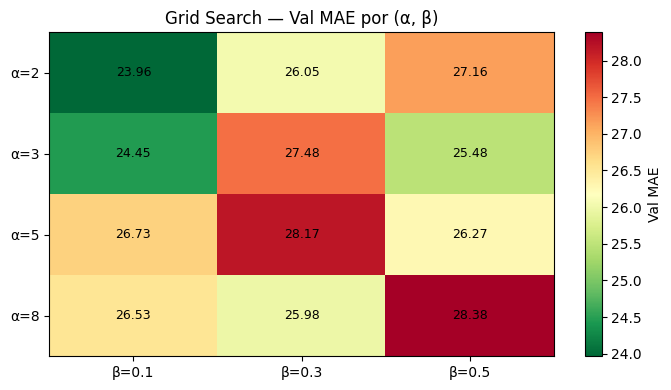

Best: α=2, β=0.1  val_MAE=23.9649


In [6]:
# Visual of grid results — heatmap of val_MAE
pivot = pd.DataFrame(grid_results).pivot(index='alpha', columns='beta', values='val_mae')

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn_r')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f'β={b}' for b in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f'α={a}' for a in pivot.index])
plt.colorbar(im, ax=ax, label='Val MAE')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f"{pivot.values[i,j]:.2f}", ha='center', va='center',
                fontsize=9, color='black')
ax.set_title('Grid Search — Val MAE por (α, β)')
plt.tight_layout()
plt.show()
print(f"Best: α={alpha_best}, β={beta_best}  val_MAE={best_row['val_mae']:.4f}")

## §6 — Modelo Final: Retrain en Train+Val → Evaluación en Test

Refit scalers en train+val combinados. Entrenar modelo ganador sin EarlyStopping  
(convergencia guiada por train loss, 200 epochs).

In [7]:
# ── Refit scalers on train+val ────────────────────────────
X_tv      = np.concatenate([X_train, X_val], axis=0)       # (142, 12, 157)
y_tv      = np.concatenate([y_train, y_val], axis=0)        # (142,)
y_peak_tv = np.concatenate([y_peak_train, y_peak_val], axis=0)  # (142,)

scaler_X_final = StandardScaler()
X_tv_s = scaler_X_final.fit_transform(
    X_tv.reshape(-1, N_FEATURES)).reshape(X_tv.shape)
X_test_final_s = scaler_X_final.transform(
    X_test.reshape(-1, N_FEATURES)).reshape(X_test.shape)

scaler_y_final = StandardScaler()
y_tv_s = scaler_y_final.fit_transform(y_tv.reshape(-1,1)).flatten()

Y_tv = np.stack([y_tv_s, y_peak_tv], axis=1)   # (142, 2)

# ── Train final model ─────────────────────────────────────
tf.random.set_seed(42)
np.random.seed(42)

model_final = build_model(alpha_best, beta_best)
cb_final = EarlyStopping(monitor='loss', patience=30,
                         restore_best_weights=True, verbose=1)
history_final = model_final.fit(
    X_tv_s, Y_tv,
    epochs=300, batch_size=16,
    callbacks=[cb_final], verbose=1
)

# ── Evaluate on test ──────────────────────────────────────
test_pred_raw = model_final.predict(X_test_final_s, verbose=0)[:, 0]
test_price    = scaler_y_final.inverse_transform(
                    test_pred_raw.reshape(-1,1)).flatten()

test_mae  = mean_absolute_error(y_test, test_price)
test_rmse = np.sqrt(mean_squared_error(y_test, test_price))
test_r2   = r2_score(y_test, test_price)

print(f"\n{'='*55}")
print(f"  RESULTADO FINAL — Test Set")
print(f"{'='*55}")
print(f"  α={alpha_best}, β={beta_best}")
print(f"  MAE  : {test_mae:.4f}   (Sesion-8 best: 27.9237)")
print(f"  RMSE : {test_rmse:.4f}")
print(f"  R²   : {test_r2:.4f}")
print(f"  Δ MAE vs Sesion-8: {test_mae - 27.9237:+.4f}")
print(f"{'='*55}")

Epoch 1/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 1.3961
Epoch 2/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.2853 
Epoch 3/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.2078 
Epoch 4/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.1673 
Epoch 5/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.1776 
Epoch 6/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0823 
Epoch 7/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0027 
Epoch 8/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0364
Epoch 9/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9545
Epoch 10/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9061 
Epoch 11/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8372 
Epoch 12/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9576 
Epoch 13/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8894 
Epoch 14/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8991 
Epoch 15/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7869
Epoch 16/300
9/9 ━━━━━━

## §7 — Predicciones en Test con Peaks/Valleys Marcados

Líneas verticales azules = extremos locales reales (argrelextrema order=3).

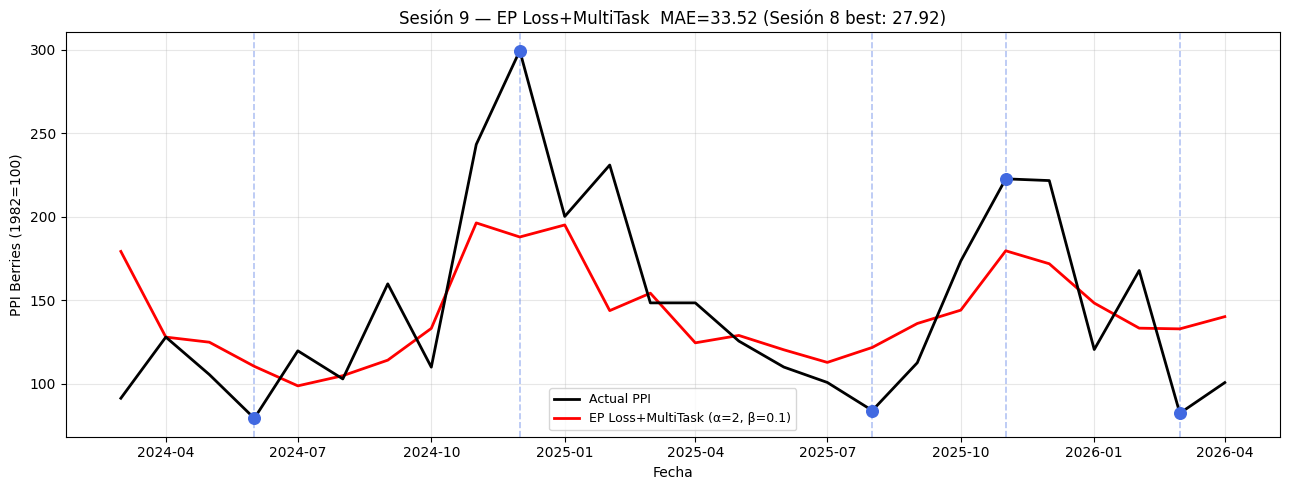

In [8]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(test_dates, y_test,    'k-',  linewidth=2, label='Actual PPI', zorder=5)
ax.plot(test_dates, test_price, 'r-', linewidth=2,
        label=f'EP Loss+MultiTask (α={alpha_best}, β={beta_best:.1f})',
        zorder=4)

# Mark actual peak/valley positions in test set
for d, v, p in zip(test_dates, y_test, y_peak_test):
    if p == 1:
        ax.axvline(pd.Timestamp(d), color='royalblue',
                   alpha=0.4, linestyle='--', linewidth=1.2)
        ax.scatter([d], [v], color='royalblue', s=70, zorder=6)

ax.set_xlabel('Fecha')
ax.set_ylabel('PPI Berries (1982=100)')
ax.set_title(
    f'Sesión 9 — EP Loss+MultiTask  MAE={test_mae:.2f} '
    f'(Sesión 8 best: 27.92)'
)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## §8 — Preguntas de Análisis

1. **¿EP Loss + multi-task supera a MAE simple?** Compara MAE test con Sesion-8 best (27.92). ¿La penalización en peaks ayudó globalmente o sólo en extremos?

2. **¿Cuál fue el α,β óptimo?** ¿Un α alto (5-8) o bajo (2-3)? ¿Sugiere que los peaks son muy distintos del resto de la serie?

3. **Observa el gráfico de forecast en peaks marcados.** ¿El modelo ahora sigue mejor los cambios de dirección? ¿O sigue suavizando los extremos?

4. **¿El heatmap del grid search muestra un patrón claro?** ¿Hay una cresta de buenos resultados a lo largo de un α o β específico?

5. **Limitación N pequeño:** Con solo 32 peaks/valleys en 168 muestras, ¿crees que la señal supervisada fue suficiente? ¿Qué harías con más datos?